# OTTO Recommender System — Data Understanding & EDA

This notebook inspects a local sample of the OTTO session-based recommender dataset.

Expected project structure:

```text
recsys-agentic-ml-platform/
├── data/
│   ├── raw/
│   │   └── otto-recsys-test.jsonl
│   └── processed/
└── notebooks/
    └── 01_otto_data_understanding.ipynb
```

The notebook intentionally starts with a limited number of sessions so the ~750 MB JSONL file does not need to be loaded fully into memory.


## 1. Imports

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


## 2. Locate the dataset

In [ ]:
# Works when Jupyter is started either from the project root or notebooks/.
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "otto-recsys-test.jsonl"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset:      {DATA_PATH}")
print(f"Exists:       {DATA_PATH.exists()}")

if DATA_PATH.exists():
    print(f"Size:         {DATA_PATH.stat().st_size / 1024**2:.2f} MB")


Project root: /home/ilkers/projects/recsys-agentic-ml-platform
Dataset:      /home/ilkers/projects/recsys-agentic-ml-platform/data/raw/otto-recsys-train.jsonl
Exists:       True
Size:         4860.50 MB


## 3. Inspect raw JSONL records

Each JSON line represents a **session** containing an ordered list of events.

- `session`: session identifier
- `aid`: article/item identifier
- `ts`: Unix timestamp in milliseconds
- `type`: `clicks`, `carts`, or `orders`


In [35]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    for _ in range(3):
        record = json.loads(next(f))
        print(json.dumps(record, indent=2)[:3000])
        print("-" * 80)


{
  "session": 0,
  "events": [
    {
      "aid": 1517085,
      "ts": 1659304800025,
      "type": "clicks"
    },
    {
      "aid": 1563459,
      "ts": 1659304904511,
      "type": "clicks"
    },
    {
      "aid": 1309446,
      "ts": 1659367439426,
      "type": "clicks"
    },
    {
      "aid": 16246,
      "ts": 1659367719997,
      "type": "clicks"
    },
    {
      "aid": 1781822,
      "ts": 1659367871344,
      "type": "clicks"
    },
    {
      "aid": 1152674,
      "ts": 1659367885796,
      "type": "clicks"
    },
    {
      "aid": 1649869,
      "ts": 1659369893840,
      "type": "carts"
    },
    {
      "aid": 461689,
      "ts": 1659369898050,
      "type": "carts"
    },
    {
      "aid": 305831,
      "ts": 1659370027105,
      "type": "orders"
    },
    {
      "aid": 461689,
      "ts": 1659370027105,
      "type": "orders"
    },
    {
      "aid": 362233,
      "ts": 1659370064916,
      "type": "clicks"
    },
    {
      "aid": 1649869,
      "ts": 1

## 4. Load a development sample

In [37]:
N_SESSIONS = 1000_000

sessions = []

with DATA_PATH.open("r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= N_SESSIONS:
            break
        sessions.append(json.loads(line))

print(f"Loaded sessions: {len(sessions):,}")


Loaded sessions: 1,000,000


## 5. Flatten sessions into an event table

In [38]:
rows = []

for session_record in sessions:
    session_id = session_record["session"]

    for event in session_record["events"]:
        rows.append({
            "session": session_id,
            "aid": event["aid"],
            "ts": event["ts"],
            "type": event["type"],
        })

df = pd.DataFrame(rows)

print(f"Shape: {df.shape}")
df.head()


: 

## 6. Data types and timestamps

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968596 entries, 0 to 968595
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   session  968596 non-null  int64 
 1   aid      968596 non-null  int64 
 2   ts       968596 non-null  int64 
 3   type     968596 non-null  object
dtypes: int64(3), object(1)
memory usage: 29.6+ MB


In [7]:
df["datetime"] = pd.to_datetime(df["ts"], unit="ms", utc=True)

df.head()


,session,aid,ts,type,datetime
0,12899779,59625,1661724000278,clicks,2022-08-28 22:00:00.278000+00:00
1,12899779,875854,1661724026702,clicks,2022-08-28 22:00:26.702000+00:00
2,12899780,1142000,1661724000378,clicks,2022-08-28 22:00:00.378000+00:00
3,12899780,582732,1661724058352,clicks,2022-08-28 22:00:58.352000+00:00
4,12899780,973453,1661724109199,clicks,2022-08-28 22:01:49.199000+00:00


## 7. Basic data-quality checks

In [8]:
print("Missing values:")
display(df.isna().sum())

print(f"\nExact duplicate rows: {df.duplicated().sum():,}")

print("\nEvent types:")
display(df["type"].value_counts())

print(f"\nTime range: {df['datetime'].min()} -> {df['datetime'].max()}")


Missing values:


session     0
aid         0
ts          0
type        0
datetime    0
dtype: int64


Exact duplicate rows: 2,147

Event types:


type
clicks    855801
carts      83618
orders     29177
Name: count, dtype: int64


Time range: 2022-08-28 22:00:00.278000+00:00 -> 2022-09-04 21:59:58.745000+00:00


In [9]:
print(f"Sessions:    {df['session'].nunique():,}")
print(f"Items:       {df['aid'].nunique():,}")
print(f"Events:      {len(df):,}")
print(f"Events/item: {len(df) / df['aid'].nunique():.2f}")


Sessions:    100,000
Items:       257,143
Events:      968,596
Events/item: 3.77


## 8. Event-type distribution

In [10]:
event_counts = df["type"].value_counts()
event_percentages = (df["type"].value_counts(normalize=True) * 100).round(2)

display(event_counts)
display(event_percentages)


type
clicks    855801
carts      83618
orders     29177
Name: count, dtype: int64

type
clicks    88.35
carts      8.63
orders     3.01
Name: proportion, dtype: float64

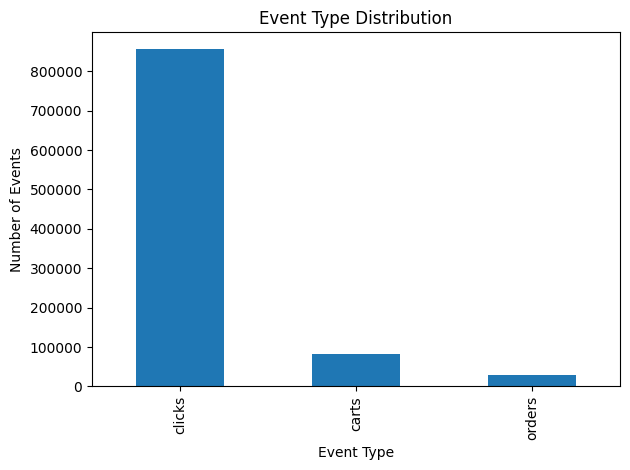

In [11]:
event_counts.plot(kind="bar")
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()


## 9. Session length

The distribution is expected to be long-tailed, so inspect percentiles rather than relying only on the mean.


In [12]:
session_lengths = df.groupby("session").size()

session_lengths.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)


count    100000.000000
mean          9.685960
std          17.197664
min           2.000000
50%           4.000000
75%          10.000000
90%          21.000000
95%          34.000000
99%          80.000000
max         485.000000
dtype: float64

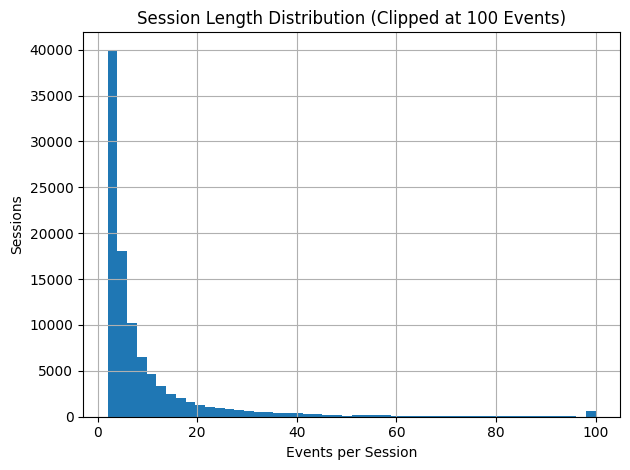

In [13]:
session_lengths.clip(upper=100).hist(bins=50)
plt.title("Session Length Distribution (Clipped at 100 Events)")
plt.xlabel("Events per Session")
plt.ylabel("Sessions")
plt.tight_layout()
plt.show()


## 10. Unique items per session

In [14]:
unique_items_per_session = df.groupby("session")["aid"].nunique()

unique_items_per_session.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)


count    100000.000000
mean          6.040600
std           9.815714
min           1.000000
50%           3.000000
75%           6.000000
90%          13.000000
95%          20.000000
99%          45.000000
max         447.000000
Name: aid, dtype: float64

## 11. Repeated session-item interactions

In [15]:
session_item_counts = df.groupby(["session", "aid"]).size()

print(f"Share of session-item pairs repeated more than once: {(session_item_counts > 1).mean():.2%}")
display(session_item_counts.describe())


Share of session-item pairs repeated more than once: 28.26%


count    604060.000000
mean          1.603476
std           1.486287
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          87.000000
dtype: float64

## 12. Most popular items

In [16]:
popular_items = (
    df.groupby("aid")
      .size()
      .sort_values(ascending=False)
)

popular_items.head(20)


aid
1460571    1209
108125      702
187686      601
836852      559
1214819     540
1751274     520
1531805     509
986164      470
585186      464
29735       441
754412      422
184976      421
1006198     417
166037      415
554660      412
811371      408
959208      391
634452      381
832192      380
1645990     356
dtype: int64

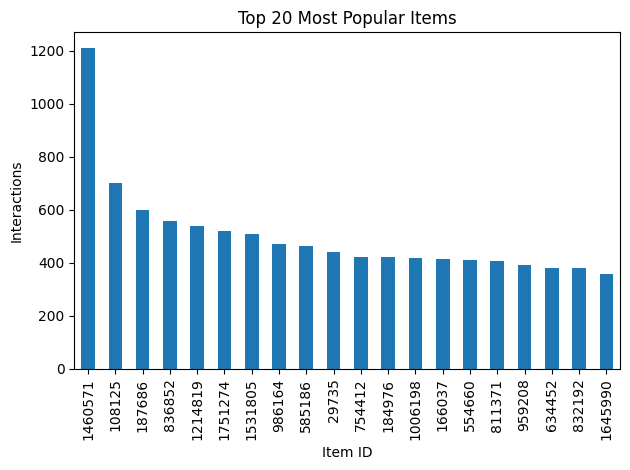

In [17]:
popular_items.head(20).plot(kind="bar")
plt.title("Top 20 Most Popular Items")
plt.xlabel("Item ID")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()


## 13. Item-popularity long tail

In [18]:
item_frequency = df["aid"].value_counts()

item_frequency.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)


count    257143.00000
mean          3.76676
std           9.83725
min           1.00000
50%           2.00000
75%           3.00000
90%           7.00000
95%          12.00000
99%          34.00000
max        1209.00000
Name: count, dtype: float64

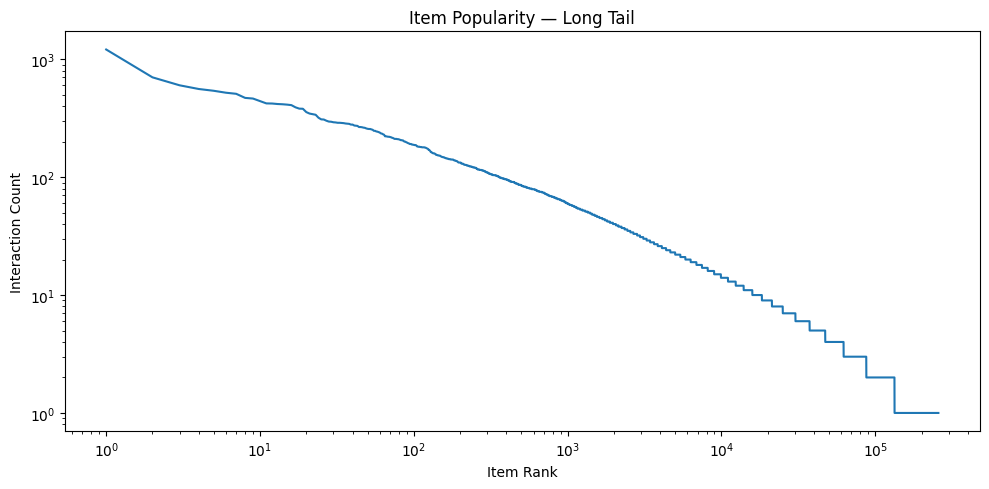

In [19]:
plt.figure(figsize=(10, 5))
plt.loglog(
    np.arange(1, len(item_frequency) + 1),
    item_frequency.values,
)
plt.title("Item Popularity — Long Tail")
plt.xlabel("Item Rank")
plt.ylabel("Interaction Count")
plt.tight_layout()
plt.show()


## 14. Event type by item

In [20]:
item_event_counts = (
    df.groupby(["aid", "type"])
      .size()
      .unstack(fill_value=0)
)

item_event_counts.head()


type,carts,clicks,orders
aid,,,
0,0,1,0
3,10,72,3
6,0,1,0
9,0,1,0
18,0,3,0


In [23]:
if "orders" in item_event_counts.columns:
    display(
        item_event_counts.sort_values("orders", ascending=False).head(20)
    )


type,carts,clicks,orders
aid,,,
1460571,89,1085,35
122983,64,217,28
634452,41,319,21
986164,48,401,21
585186,36,407,21
166037,91,305,19
1531805,51,440,18
1768724,30,95,18
544144,61,263,18


## 15. Simple item conversion signals

These raw ratios are exploratory only. Low-support items can produce misleadingly high ratios, so production features should later use support thresholds and/or smoothing.


In [24]:
for col in ["clicks", "carts", "orders"]:
    if col not in item_event_counts.columns:
        item_event_counts[col] = 0

item_event_counts["cart_per_click"] = (
    item_event_counts["carts"]
    / item_event_counts["clicks"].clip(lower=1)
)

item_event_counts["order_per_click"] = (
    item_event_counts["orders"]
    / item_event_counts["clicks"].clip(lower=1)
)

item_event_counts.sort_values(
    ["order_per_click", "orders"],
    ascending=False,
).head(20)


type,carts,clicks,orders,cart_per_click,order_per_click
aid,,,,,
1536224,6,1,9,6.0,9.0
820824,4,1,5,4.0,5.0
222307,7,2,9,3.5,4.5
215618,4,1,4,4.0,4.0
429249,4,0,4,4.0,4.0
477887,4,1,4,4.0,4.0
497116,5,1,4,5.0,4.0
638601,4,1,4,4.0,4.0
747928,8,1,4,8.0,4.0


## 16. Session duration

In [25]:
session_time = (
    df.groupby("session")["ts"]
      .agg(["min", "max"])
)

session_time["duration_minutes"] = (
    session_time["max"] - session_time["min"]
) / 1000 / 60

session_time["duration_minutes"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)


count    100000.000000
mean       1780.192145
std        2833.851040
min           0.000000
50%          43.979442
75%        2858.727462
90%        7128.657650
95%        8673.856301
99%        9396.255757
max       10069.922350
Name: duration_minutes, dtype: float64

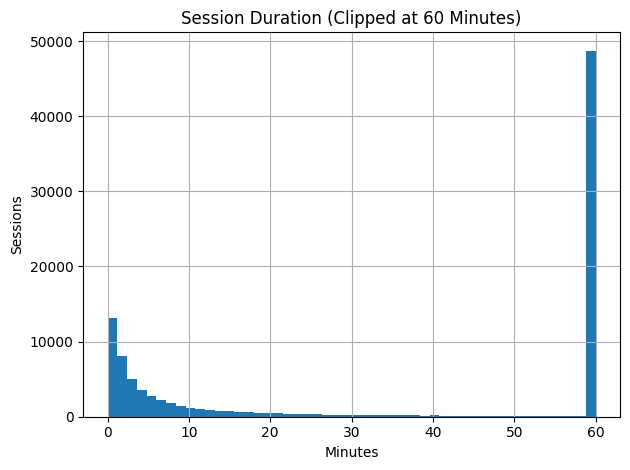

In [26]:
session_time["duration_minutes"].clip(upper=60).hist(bins=50)
plt.title("Session Duration (Clipped at 60 Minutes)")
plt.xlabel("Minutes")
plt.ylabel("Sessions")
plt.tight_layout()
plt.show()


## 17. Temporal activity

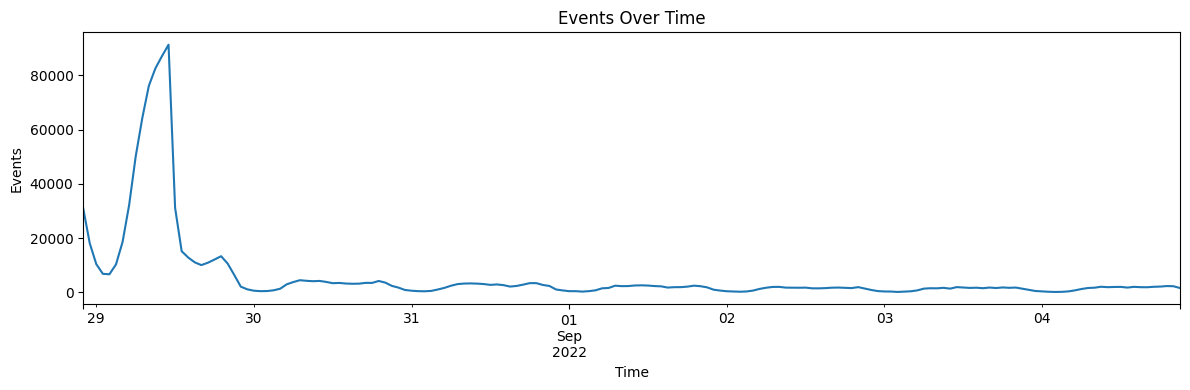

In [27]:
events_by_hour = (
    df.set_index("datetime")
      .resample("h")
      .size()
)

events_by_hour.plot(figsize=(12, 4))
plt.title("Events Over Time")
plt.xlabel("Time")
plt.ylabel("Events")
plt.tight_layout()
plt.show()


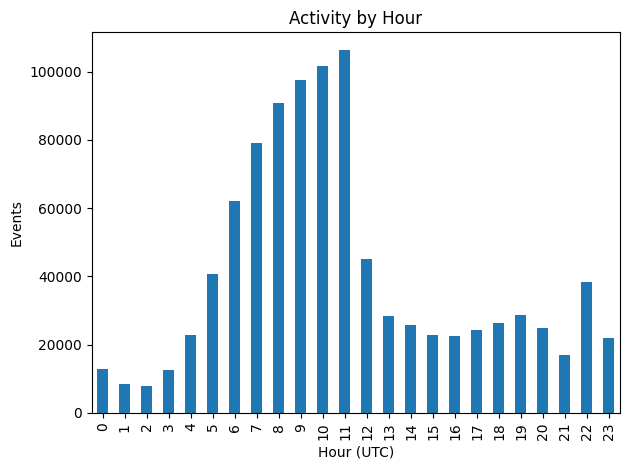

In [28]:
df["hour"] = df["datetime"].dt.hour

df.groupby("hour").size().plot(kind="bar")
plt.title("Activity by Hour")
plt.xlabel("Hour (UTC)")
plt.ylabel("Events")
plt.tight_layout()
plt.show()


## 18. Inspect session sequences

These ordered sequences are the core input representation for later session-based and sequential recommendation models such as Item2Vec, GRU4Rec, SASRec, and TRON.


In [29]:
sample_sessions = (
    df.sort_values(["session", "ts"])
      .groupby("session")
      .agg(
          items=("aid", list),
          events=("type", list),
      )
)

sample_sessions.head(10)


,items,events
session,,
12899779,"[59625, 875854]","[clicks, clicks]"
12899780,"[1142000, 582732, 973453, 736515, 1142000, 260305]","[clicks, clicks, clicks, clicks, clicks, clicks]"
12899781,"[141736, 199008, 57315, 194067, 199008, 199008, 199008, 199008, 199008, 199008, 918667, 918667]","[clicks, clicks, clicks, clicks, clicks, clicks, carts, clicks, clicks, clicks, clicks, carts]"
12899782,"[1669402, 1494780, 1494780, 1494780, 1494780, 1674681, 602722, 1596098, 45034, 603159, 413962, 4...","[clicks, clicks, clicks, clicks, carts, clicks, clicks, clicks, clicks, clicks, clicks, carts, c..."
12899783,"[255297, 1114789, 255297, 300127, 198385, 300127, 1729553, 1216820, 1754419, 607638, 1817895, 45...","[clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks,..."
12899784,"[1036375, 1269952, 476216, 1579935, 1546830, 22981, 1190477, 416846, 1694129, 292022, 1268781, 9...","[clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks,..."
12899785,"[1784451, 1169631, 95259, 970225, 95259, 608210, 95259, 1308865, 179800, 383003, 1444536, 125486...","[clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks, clicks,..."
12899786,"[955252, 955252, 955252, 955252, 955252]","[clicks, carts, orders, clicks, clicks]"
12899787,"[1682750, 1682750, 1682750, 1682750, 1024433, 740562]","[clicks, carts, carts, carts, clicks, clicks]"


## 19. Additional behavioral summary

In [30]:
session_summary = (
    df.groupby("session")
      .agg(
          events=("aid", "size"),
          unique_items=("aid", "nunique"),
          start_time=("datetime", "min"),
          end_time=("datetime", "max"),
      )
)

session_summary["duration_minutes"] = (
    session_summary["end_time"] - session_summary["start_time"]
).dt.total_seconds() / 60

session_summary.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)


,events,unique_items,duration_minutes
count,100000.000000,100000.000000,100000.000000
mean,9.685960,6.040600,1780.192145
std,17.197664,9.815714,2833.851040
min,2.000000,1.000000,0.000000
50%,4.000000,3.000000,43.979442
75%,10.000000,6.000000,2858.727462
90%,21.000000,13.000000,7128.657650
95%,34.000000,20.000000,8673.856301
99%,80.000000,45.000000,9396.255757
max,485.000000,447.000000,10069.922350


## 20. Save the processed development sample

Parquet is substantially faster and more convenient than repeatedly parsing the source JSONL during development.


In [32]:
df

,session,aid,ts,type,datetime,hour
0,12899779,59625,1661724000278,clicks,2022-08-28 22:00:00.278000+00:00,22
1,12899779,875854,1661724026702,clicks,2022-08-28 22:00:26.702000+00:00,22
2,12899780,1142000,1661724000378,clicks,2022-08-28 22:00:00.378000+00:00,22
3,12899780,582732,1661724058352,clicks,2022-08-28 22:00:58.352000+00:00,22
4,12899780,973453,1661724109199,clicks,2022-08-28 22:01:49.199000+00:00,22
...,...,...,...,...,...,...
968591,12999777,834646,1661774652945,clicks,2022-08-29 12:04:12.945000+00:00,12
968592,12999777,653773,1661774677161,clicks,2022-08-29 12:04:37.161000+00:00,12
968593,12999778,676890,1661774546120,clicks,2022-08-29 12:02:26.120000+00:00,12
968594,12999778,676890,1661774549166,clicks,2022-08-29 12:02:29.166000+00:00,12


In [31]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / f"otto_test_{N_SESSIONS // 1000}k_sessions.parquet"

df.to_parquet(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Size:  {OUTPUT_PATH.stat().st_size / 1024**2:.2f} MB")


Saved: /home/ilkers/projects/recsys-agentic-ml-platform/data/processed/otto_test_100k_sessions.parquet
Size:  17.03 MB


## Next Step

The test file is useful for schema inspection and exploratory analysis, but model development should use the OTTO training data.

The next notebook will:

1. Prepare the training dataset.
2. Construct a temporal validation strategy.
3. Define the recommendation prediction task.
4. Establish Recall@K, MRR@K, NDCG@K, and HitRate@K.
5. Implement the first popularity and co-visitation baselines.
